<a href="https://colab.research.google.com/github/blancaorozco/analysis-ever-pick/blob/main/Proyecto__ladb_mobility_economy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Evaluar la Relacion Entre Movilidad Urbana y Productivadad** **Eaconómica**

## Introducción

El objetivo fue **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello trabajé con datos reales de TomTom Traffic Index y OECD Cities, que limpié, combiné y analicé para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargé y exploré

Antes de limpiar o combinar los datos, fue necesario **familiarizarse con la estructura de ambos datasets**.
En esta etapa, se validaron que los archivos se cargaran correctamente, conocer sus columnas y tipos de datos, y detectar posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Acciones:**
- Importar las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Cargar los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guardar los DataFrames en las variables `traffic` y `eco`.
- Mostrar las primeras 5 filas de cada DataFrame.


In [9]:
# importación de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
# carga de archivos
traffic = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data sets/tomtom_traffic.csv')
eco = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data sets/oecd_city_economy.csv')

In [11]:
# muestra de las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [12]:
# muestra de las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


 No se usó `print()` la tabla se ve mejor.


---

## 🧩Paso 2: Exploré, limpié y preparé los datos

Antes de combinar los datasets, inspeccioné su estructura, tipos de datos, columnas y valores faltantes.
Anoté las columnas que necesitaban limpieza y luego estandaricé los nombres de columnas.

### 2.1 Exploración de la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Acciones:**

- Use `.info()` para conocer la estructura de ambos DataFrames.
- Muestré los primeros 3 renglones de cada DF.
- Identifiqué si los detalles de cada DF estaban bien o si requierían correcciones y escribí mis conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato tienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?


In [13]:
# Examiné la estructura de traffic
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo object
- Es necesario cambiarlas a tipo fecha

In [14]:
# Examiné la estructura de eco
eco.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, PM2.5 (μg/m³) y Population (M) son de tipo object cuando deberían ser numéricas.


### 2.2 Renombré columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Acciones:**

- Cambié los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifiqué que los cambios se hayan aplicado correctamente usando `.columns`.


In [15]:
# Estandaricé los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country':'country',
    'City': 'city',
    'UpdateTimeUTC':'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

# verifiqué cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [16]:
# Estandaricé los nombres de las columnas de eco
eco =eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25',
    'Population (M)': 'population_m'
})

# verifiqué cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corregí formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Acciones:**

- Conviertí las columnas de fecha de `traffic` a formato `datetime`. Hice el cambio a prueba de errores.
- En el dataset `eco`, limpié los valores numéricos:
    - En `city_gdp_capita`: eliminé separadores de miles (`.`) y reemplacé las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: eliminé el símbolo de porcentaje (`%`) y reemplacé las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplace las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, creé una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [17]:
# Convertí las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] =  pd.to_datetime(traffic['update_time_utc_week_ago'])

# verifiqué el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   country                          1004464 non-null  object        
 1   city                             1004464 non-null  object        
 2   update_time_utc                  1004464 non-null  datetime64[ns]
 3   jams_delay                       1004464 non-null  float64       
 4   traffic_index_live               1004464 non-null  float64       
 5   jams_length_kms                  1004464 non-null  float64       
 6   jams_count                       1004464 non-null  float64       
 7   traffic_index_week_ago           1004464 non-null  float64       
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins  1004464 non-null  float64       
 10  travel_time_hist_per_10kms_min

In [18]:
# Limpié separadores y conviertí columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

# Calculé la población total en unidades absolutas (Multiplicando * 1000000)
eco['population_m'] = eco['population_m'] * 1000000

# verifiqué el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
dtypes: float64(3), int64(1), object(3)
memory usage: 1.8+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13600000.0


In [19]:
eco.head()

,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13600000.0
3,2023,brasilia,Brazil,15999.0,8.3,"13,50",4700000.0
4,2023,salvador,Brazil,8761.0,13.1,"16,00",3900000.0



---

## 🧩Paso 3: Extraje el año y filtré

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraje columna año y filtré por 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Acciones:**

- Como el DataFrame `traffic` no tiene una columna de año, utilicé el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtré las filas donde el año era **2024**.
- Utilicé `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [20]:
# Extraje el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year

# Verifiqué cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [21]:
# Filtré y cree nuevas df con los registros del año 2024
traffic_2024 = traffic[traffic['year']==2024].copy()
eco_2024 = eco[eco['year']==2024].copy()

# Revicé dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3900000.0



---

## 🧩Paso 4: Analicé y resumí datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calculé los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calculé promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Acciones**

- Agrupé los datos por `city`, `country` y `year`.
- Calculé el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guardé el resultado como `traffic_city_year_2024`, mantuve las columnas como variables (no índices).


<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [22]:
# Calculé los  promedios de trafico por ciudad, país y año
col_p = ['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins']
traffic_city_year_2024 = traffic.groupby(['city','country','year'])[col_p].mean().reset_index()

# Verifiqué el resultado
traffic_city_year_2024

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,a-coruna,ESP,2025,11.323684,11.055921,1.161513,3.105263,0.402193,15.839864,15.437671
2,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
3,aachen,DEU,2025,16.278289,18.269737,3.400000,4.144737,0.648249,13.347184,12.698935
4,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
...,...,...,...,...,...,...,...,...,...,...
769,zaragoza,ESP,2025,8.076316,11.259868,1.041447,2.651316,0.394271,13.948808,13.554538
770,zurich,CHE,2024,99.947969,23.029270,19.140149,23.118392,0.688030,14.441662,13.753633
771,zurich,CHE,2025,21.054934,12.450658,6.176316,6.240132,-0.279422,13.062377,13.341799
772,zwolle,NLD,2024,8.804438,15.381371,1.815246,2.101933,0.323400,9.928753,9.605353


Pregunas a responder:

- ¿Cuál ciudad tendrá el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuté esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`

In [23]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
442,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
704,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
492,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
400,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
422,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
25,almere,NLD,2025,1.833667,5.040000,0.214333,0.596667,-0.063112,9.455774,9.518886
223,dunedin,NZL,2025,1.644408,11.023026,0.306250,0.526316,0.101581,15.436593,15.335011
291,hamilton,NZL,2025,1.448658,7.892617,0.161745,0.473154,-0.197995,13.097767,13.295761
234,el-paso,USA,2024,0.299024,2.340435,0.031114,0.078118,-0.250676,10.690269,10.940945


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de Mexico


---

## 🧩Paso 5: Uní movilidad y economía

Combinar datasets permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Uni tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Acciones:**
- Seleccioné solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usé `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Uní ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantuve solo las ciudades y años presentes en ambos datasets.
- Guardé el resultado en una nueva variable llamada `merged`mostrando las primeras 5 filas.


<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [24]:
# Seleccioné columnas clave de tráfico y economía
left_cols = ['city', 'country', 'year', 'jams_delay', 'traffic_index_live', 'jams_count',
       'travel_time_live_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population_m']

# Usé .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets donde solo coincidan los datos en amabas tablas
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')


# Mostré las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_count,travel_time_live_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population_m
0,belo-horizonte,BRA,2024,263.047879,19.428946,68.805422,18.304538,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,230.566550,24.992185,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,27.280140,13.338658,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,137.359860,17.907916,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,46.898164,17.258700,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualicé y análicé relaciones

Ahora que el dataset está limpio y unificado, es momento de **visualizar patrones**.
Los gráficos nos ayudan a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualicé relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Acciones:**
- Usé las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualicé la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualice la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **comparé ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparecen ambos indicadores.
- Agregué título y etiquetas a los ejes de tus gráficos.

Dentro de los parentesis del boxplot, agregé `showmeans=True` para ver la media en el gráfico.

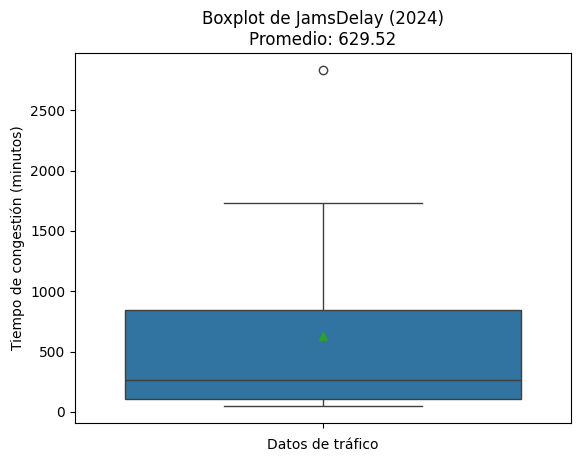

In [25]:
# Creé boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, y="jams_delay", showmeans=True)

# Obtuve el promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.ylabel('Tiempo de congestión (minutos)')
plt.xlabel('Datos de tráfico')

plt.show()


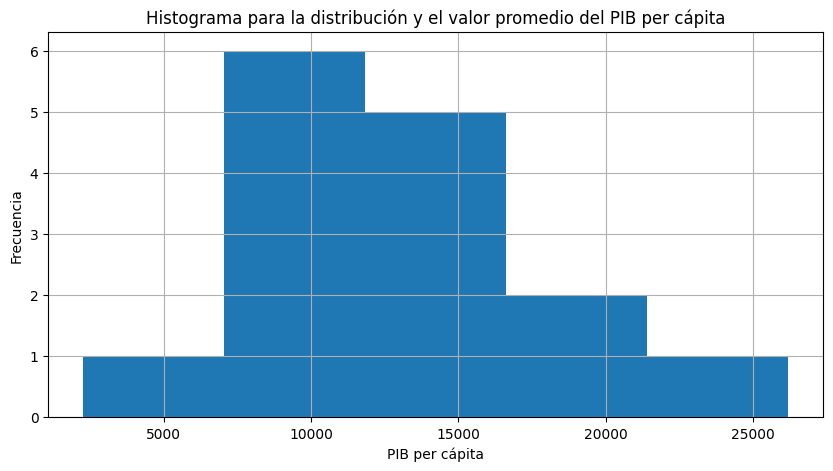

In [26]:
# Creé un histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist(bins=5, figsize=(10, 5))
plt.title('Histograma para la distribución y el valor promedio del PIB per cápita')
plt.xlabel('PIB per cápita')
plt.ylabel('Frecuencia')
plt.show()

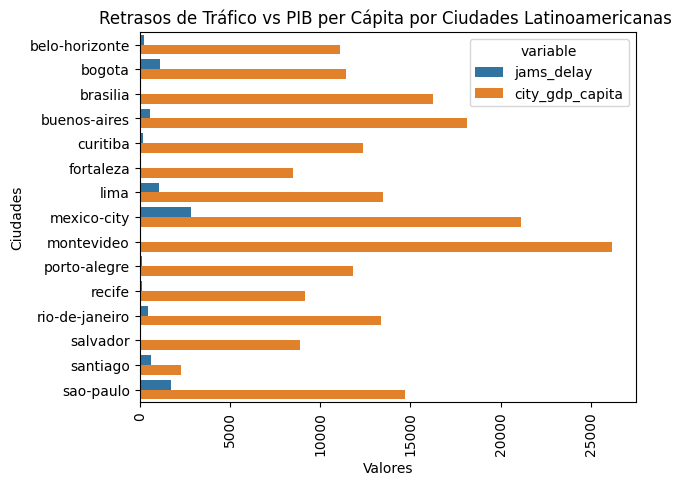

In [27]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged_g = merged.melt(id_vars="city", value_vars=["jams_delay","city_gdp_capita"])
sns.barplot(data=merged_g, y='city', x='value', hue='variable')

plt.title('Retrasos de Tráfico vs PIB per Cápita por Ciudades Latinoamericanas ')
plt.ylabel('Ciudades')
plt.xlabel('Valores')
plt.xticks(rotation=90)

plt.show()

In [28]:
m =merged['city'].nunique()
print(m)

15


Antes del `plt.show()` agregé el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

Escribe tus comentarios: Aplica en la mayoria, pero hay la esepción como Brasilia, donde el PIB es elevado, sin embargo el tiempo de retraso no es muy alto.


---

## 🧩Paso 7: Exporté y documenté resultados


### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Acciones:**

- Exporté el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usé`index=False` para no incluir el índice.


In [29]:
# Exportación del dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo (plantilla)


**Contexto:**  
- La relación entre movilidad humana, congestión, tiempos de viaje y productividad económica per cápita, es directa y bastante fuerte, ya que pueden impulsar o frenar el desarrollo de una ciudad o región
- Se utilizaron las variables country, city, year, jams_delay, city_gdp_capita, para comparar las demoras en tranporte en las ciudades con alta productividad económica.

**Cobertura de datos:**  
- Se enfocó el analisisd en el año 2024, 15 ciudades y 7 paises latinoamericanos

**Metodología (alto nivel):**  
- Solución aplicada para evitar errores de sintaxis y facilitar el código.
1. Convertir a formato snake_case uniforme:
   Country → country
   UpdateTimeUTC → update_time_utc
   City GDP/capita → city_gdp_capita
   PM2.5 (μg/m³) → pm25
       
2. Corrección de tipos de datos. Columnas numéricas almacenadas como texto (object) y valores numéricos con formato europeo:
    traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
    eco['city_gdp_capita'] = eco['city_gdp_capita'].str.replace('.', '').str.replace(',', '.').astype(float)
    eco['unemployment_pct'] = eco['unemployment_pct'].str.replace('%', '').str.replace(',', '.').astype(float)

3. Limpieza de formatos numéricos:
   Separadores de miles: 15.782,00
   Símbolos especiales: 6.2%
   Formato decimal europeo: 15,2
  
4. Agregación de columna y filtrado temporal:  
  * Extracción de año: traffic['year'] = traffic['update_time_utc'].dt.year
  * Filtrado por período relevante: traffic_2024 = traffic[traffic['year']==2024].copy()

5. Múltiples registros diarios por ciudad. Calcular promedios anuales:
    traffic_city_year_2024 = traffic.groupby(['city','country','year'])[col_p].mean()

- Se resumió múltiples registros en un solo valor representativo. El dataset de tráfico tiene múltiples registros diarios por ciudad (cada hora, cada día) y para el análisis necesitabamos un valor anual por ciudad, para comparaciones más claras y estables.
Asi, calculamos el promedio de las métricas de tráfico seleccionadas, convirtiendo miles de registros diarios en un solo registro anual por ciudad.
   traffic_city_year_2024 = traffic.groupby(['city','country','year'])[col_p].mean().reset_index()

6. La unión INNER combina las dos datasets de tráfico y economía manteniendo solo las filas que existen en ambos:
   merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

7. Usamos el histograma del PIB per cápita para análisis de distribuciones.  Para la detección de outliers se usó boxplot de congestión vehicular. Para el análisis de tendencias generales se usó el Gráfico de barras comparativo.

**Hallazgos iniciales:**  
- Ciudades con mayor PIB tienden a tener más congestión a exepción como Brasilia (alto PIB, baja congestión).
  La mayoría de ciudades tienen PIB medio-bajo, entre $8,000 y $18,000 USD.
  
- Bogotá mostró anomalía extrema de congestión > 1000 minutos.
  Brasilia tiene una anomalía positiva, alto PIB ($16,251) + Baja congestión (~101 min)
  Ciudad de México mostró anomalía com mayor congestión global (jams_delay: 2,833 min)


**Recomendaciones**  

1. Validar datos de Bogotá: Verificar fuentes y metodología, presenta una de las combinación más críticas: Alta congestión: 1,141 minutos de retraso (2º lugar mundial) PIB relativamente bajo: $11,442 USD per cápita

2. Estudiar caso Brasilia: Identificar factores de éxito

3. Ampliar cobertura: Incluir más ciudades latinoamericanas

4. Análisis temporal: Comparar con años anteriores

5. Prioridad máxima de Ciudad de México: Densidad poblacional, urgencia de inversión en transporte.
